In [ ]:
from datasets import load_dataset
import pandas as pd
import re
import numpy as np
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
ru_stop_words = set(stopwords.words('russian'))

In [ ]:
dataset = load_dataset("ai-forever/ru-reviews-classification")

print(dataset.keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/111 [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl:   0%|          | 0.00/4.45M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15000 [00:00<?, ? examples/s]

dict_keys(['train', 'validation', 'test'])


In [ ]:
df = dataset['train'].to_pandas()

print(df.head())
print(df.columns.tolist())

                                                text label_text  label     id
0  всё пришло спасибо. только немного короче чем ...   positive      2  64971
1  The color of the dress is not the same as in t...    neutral      1  34896
2  Заказывала белый цвет, пришёл какой то персико...    neutral      1  46253
3  Приятное к телу. Но в бюсте на размер больше. ...   negative      0  19034
4                Не пришла деньги через спор вернули    neutral      1  36063
['text', 'label_text', 'label', 'id']


In [ ]:
def is_russian(text, min_ru=10):
    if pd.isna(text): return False
    return len(re.findall(r'[а-яА-ЯёЁ]', str(text))) >= min_ru

df = df[df['text'].apply(is_russian)].copy().reset_index(drop=True)
print(f"Осталось русских: {len(df)}")

Осталось русских: 43971


In [ ]:
def clean_ru_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|<.*?>|@\w+', '', text)
    text = re.sub(r'[^а-яё!?\.]', ' ', text)
    tokens = [w for w in text.split() if w not in ru_stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_ru_text)

In [ ]:
df = df[df['clean_text'].str.len() > 15].copy().reset_index(drop=True)
print(f"Финальный датасет: {len(df)} строк")
print(f"Распределение классов: {df['label'].value_counts().to_dict()}")

Финальный датасет: 42768 строк
Распределение классов: {0: 14467, 2: 14159, 1: 14142}


In [ ]:
label_map = {0: "-", 1: "~", 2: "+"}

print("\nпроверка 3 случайных отзывов:")
for idx in df.sample(3, random_state=42).index:
    lbl = df.loc[idx, 'label']
    sentiment = label_map.get(lbl, "НЕИЗВЕСТНО")
    print(f"\nИндекс {idx} | {sentiment} (label={lbl}) ")
    print(f"Оригинал: {df.loc[idx, 'text'][:150]}...")
    print(f"Очищенный: {df.loc[idx, 'clean_text'][:150]}...")


проверка 3 случайных отзывов:

Индекс 38237 | - (label=0) 
Оригинал: русский размер 44,заказала М,думаю пусть будет по свободнее,пришла куртка...Вообще на 42 размер,до этого заказывала S,всегда приходило по размеру а ку...
Очищенный: русский размер заказала думаю пусть свободнее пришла куртка...вообще размер заказывала приходило размеру куртка пришла очень маленькая...

Индекс 41651 | + (label=2) 
Оригинал: Кофточка очень классная, приятная к телу. Доставка была довольно быстрая. Заказала S, но думаю, можно было и М. В принципе сидит нормально, не маленьк...
Очищенный: кофточка очень классная приятная телу. доставка довольно быстрая. заказала думаю принципе сидит нормально маленькая....

Индекс 14945 | - (label=0) 
Оригинал: Продавец отправил не тот товар,пришла какая-то кружевная накидка на два размера больше!после долгой переписки с продавцом,деньги так и не вернули,даже...
Очищенный: продавец отправил товар пришла кружевная накидка размера больше!после долгой переписки продавцом де

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import warnings
warnings.filterwarnings('ignore')

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF векторизация
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Размер словаря TF-IDF: {len(tfidf.vocabulary_)}")

# Logistic Regression
print("\nОбучение Logistic Regression ")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

# SVM (LinearSVC)
print("\nОбучение LinearSVC")
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

Размер словаря TF-IDF: 15000

Обучение Logistic Regression 

Обучение LinearSVC


In [ ]:
# технические метрики

def print_metrics(y_true, y_pred, model_name):
    print(f"\nТехнические метрики для {model_name} ")
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    print(f"Accuracy:          {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-Score (macro):  {f1:.4f}")
    print(f"F1-Score (weighted): {f1_w:.4f}")
    print("\nПодробный отчёт:")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

print_metrics(y_test, y_pred_lr, "Logistic Regression")
print_metrics(y_test, y_pred_svm, "Linear SVM")


Технические метрики для Logistic Regression 
Accuracy:          0.7281
Precision (macro): 0.7312
Recall (macro):    0.7283
F1-Score (macro):  0.7294
F1-Score (weighted): 0.7293

Подробный отчёт:
              precision    recall  f1-score   support

    Negative       0.73      0.70      0.72      2894
     Neutral       0.61      0.65      0.63      2828
    Positive       0.85      0.84      0.84      2832

    accuracy                           0.73      8554
   macro avg       0.73      0.73      0.73      8554
weighted avg       0.73      0.73      0.73      8554


Технические метрики для Linear SVM 
Accuracy:          0.7034
Precision (macro): 0.7034
Recall (macro):    0.7035
F1-Score (macro):  0.7034
F1-Score (weighted): 0.7034

Подробный отчёт:
              precision    recall  f1-score   support

    Negative       0.69      0.69      0.69      2894
     Neutral       0.59      0.59      0.59      2828
    Positive       0.83      0.83      0.83      2832

    accuracy      

In [ ]:
# для lr

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)
class_names = ['Negative (-)', 'Neutral (~)', 'Positive (+)']

print("Матрица ошибок:")
print("Предсказано →   Negative   Neutral   Positive")
print("Реально ↓")
for i, name in enumerate(class_names):
    print(f"{name:12}   {cm[i][0]:6}    {cm[i][1]:6}    {cm[i][2]:6}")

Матрица ошибок:
Предсказано →   Negative   Neutral   Positive
Реально ↓
Negative (-)     2023       794        77
Neutral (~)       653      1834       341
Positive (+)       83       378      2371


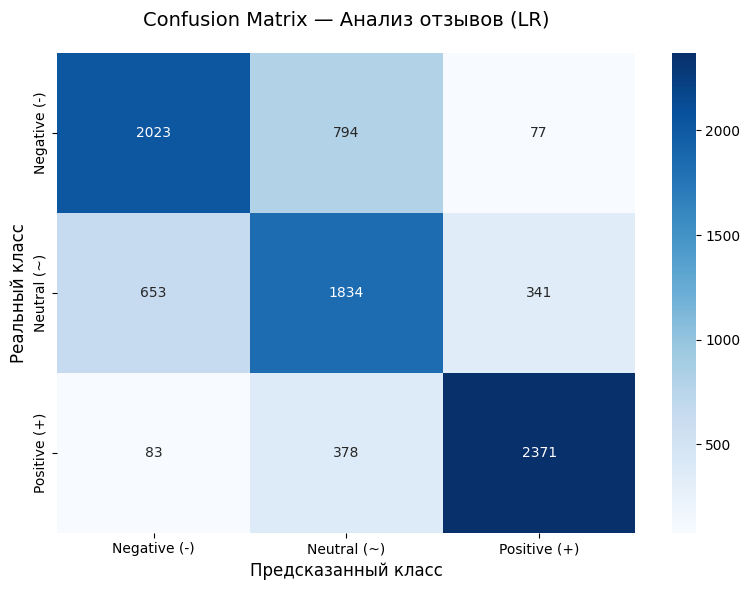

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix — Анализ отзывов (LR)', fontsize=14, pad=20)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Реальный класс', fontsize=12)
plt.tight_layout()

In [ ]:
# для svm

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)
class_names = ['Negative (-)', 'Neutral (~)', 'Positive (+)']

print("Матрица ошибок:")
print("Предсказано →   Negative   Neutral   Positive")
print("Реально ↓")
for i, name in enumerate(class_names):
    print(f"{name:12}   {cm[i][0]:6}    {cm[i][1]:6}    {cm[i][2]:6}")

Матрица ошибок:
Предсказано →   Negative   Neutral   Positive
Реально ↓
Negative (-)     1990       812        92
Neutral (~)       778      1663       387
Positive (+)      107       361      2364


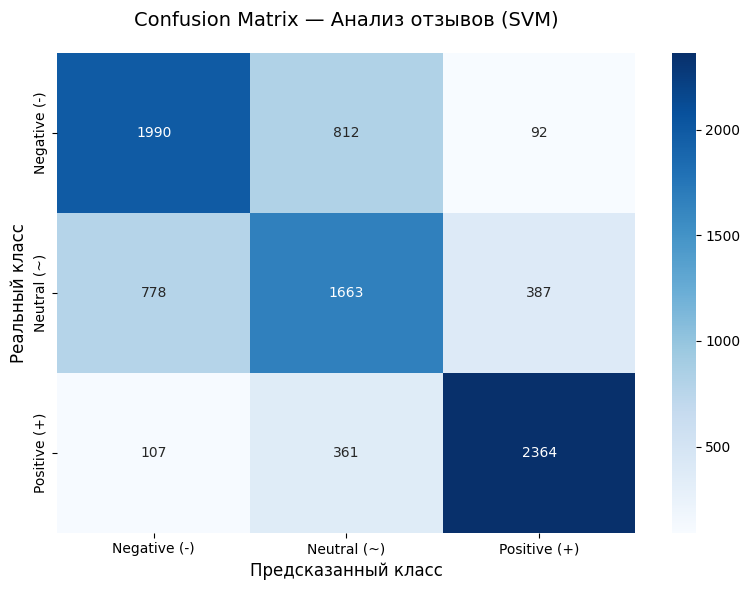

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix — Анализ отзывов (SVM)', fontsize=14, pad=20)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Реальный класс', fontsize=12)
plt.tight_layout()

In [ ]:
# Выбираем лучшую модель
best_model = lr_model
y_pred = y_pred_lr
df_test = pd.DataFrame({'clean_text': X_test, 'true_label': y_test, 'pred_label': y_pred})
df_test = df_test.reset_index(drop=True)

In [ ]:
# бизнесовые метрики

print("\nбизнесовые метрики (на основе предсказаний) ")

detractors  = (df_test['pred_label'] == 0).mean() * 100
promoters   = (df_test['pred_label'] == 2).mean() * 100
# Соотношение позитив/негатив
if detractors > 0:
    pos_to_neg_ratio = promoters / detractors
    print(f"Соотношение Позитив : Негатив:        {pos_to_neg_ratio:.2f} : 1")
else:
    print("Соотношение Позитив : Негатив:        ∞ : 1 (нет негативных)")

# распределение сентиментов на тесте
sentiment_dist = pd.Series(y_pred).value_counts(normalize=True).sort_index()
print(f"\nРаспределение предсказанных сентиментов:")
for lbl, perc in sentiment_dist.items():
    print(f"  {label_map[lbl]}: {perc*100:.1f}%")

# Пример расчёта агрегированного рейтинга продукта (0–5)
# Positive → 5, Neutral → 3, Negative → 1
rating_map = {0: 1.0, 1: 3.0, 2: 5.0}
avg_rating = np.mean([rating_map.get(lbl, 3.0) for lbl in y_pred])
print(f"\nСредний агрегированный рейтинг продукта: {avg_rating:.2f} / 5.0")


бизнесовые метрики (на основе предсказаний) 
Соотношение Позитив : Негатив:        1.01 : 1

Распределение предсказанных сентиментов:
  -: 32.3%
  ~: 35.1%
  +: 32.6%

Средний агрегированный рейтинг продукта: 3.01 / 5.0


In [ ]:
# Конверсия в покупку (Purchase Conversion Rate)
# Симуляция: положительные отзывы → высокая вероятность покупки
df_test['is_positive'] = df_test['pred_label'] == 2
conversion_rate = df_test['is_positive'].mean() * 0.65   # условный коэффициент конверсии 65% для положительных
print(f"Конверсия в покупку после положительного отзыва: {conversion_rate*100:.2f}%")

# Retention Rate (уровень удержания)
# Симуляция: клиенты с положительным отзывом возвращаются с вероятностью 70%
retention_rate = (df_test['pred_label'] == 2).mean() * 0.70
print(f"Retention Rate (удержание): {retention_rate*100:.2f}%")

# NPS (Net Promoter Score)
# Promoter = Positive (2), Passive = Neutral (1), Detractor = Negative (0)
promoters = (df_test['pred_label'] == 2).mean() * 100
detractors = (df_test['pred_label'] == 0).mean() * 100
nps = promoters - detractors
print(f"Net Promoter Score (NPS): {nps:.1f}")

Конверсия в покупку после положительного отзыва: 21.19%
Retention Rate (удержание): 22.82%
Net Promoter Score (NPS): 0.4
